# TP 5: PCA and Anomaly Detection

## 📝 Exercise 1: PCA on digits

In this exercise, you will apply **Principal Component Analysis (PCA)** to the `sklearn digits` dataset to understand dimensionality reduction and anomaly detection. You will analyze how data can be effectively compressed while preserving information.

### Part 0: Data Loading and Exploration

- Load the digits dataset from sklearn
- Explore the shape and characteristics of the data
- Visualize a sample of digits

Dataset shape: (1797, 64)
Target classes: [0 1 2 3 4 5 6 7 8 9]
Number of features: 64
Number of samples: 1797


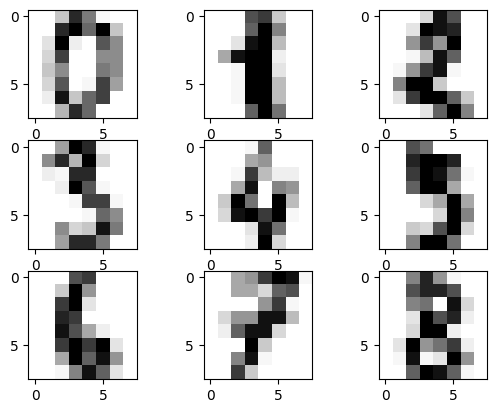

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target

print("Dataset shape:", X.shape)
print("Target classes:", np.unique(y))
print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

for i in range(1,10):
    plt.subplot(330+i)
    plt.imshow(digits.images[i-1],cmap='Greys')

plt.show() 

### Part 1: Implement PCA for 2D Projection

Apply PCA to reduce the digit images from 64 dimensions to 2 dimensions. Then create a visualization showing how the different digit classes are distributed in this 2D space.

1. Create a PCA model with 2 principal components

2. Transform the data to the 2D space using your model

3. Create a scatter plot where:
    - The x-axis is the first principal component
    - The y-axis is the second principal component
    - Each digit class (0-9) has a different color
    - Add a colorbar to show which color represents which digit

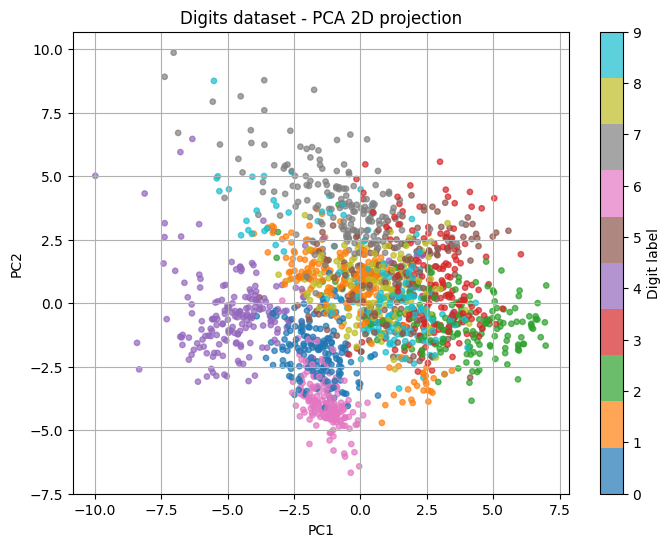

Explained variance ratio (2D): [0.12033916 0.09561054]
Total explained variance (2D): 0.21594970500832794


In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="tab10", s=15, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits dataset - PCA 2D projection")
cbar = plt.colorbar(sc)
cbar.set_label("Digit label")
plt.grid(True)
plt.show()

print("Explained variance ratio (2D):", pca_2d.explained_variance_ratio_)
print("Total explained variance (2D):", pca_2d.explained_variance_ratio_.sum())


### Part 2: K-means Clustering with 10 Clusters

In the 2D PCA space you created in Exercise 1, apply K-means clustering to create 10 clusters (one for each digit). Then evaluate how well the clusters match the true digit labels.

1. Apply K-means with k=10 clusters to your 2D PCA data:
    - You may need to try multiple initializations to get exactly 10 non-empty clusters

2. Assign cluster labels by finding which digit class is most common in each cluster:
    - For each cluster, find the majority digit label
    - Assign this label to all points in that cluster

3. Evaluate the clustering using three metrics:
    - Precision: For each true digit class, what fraction of its samples were clustered correctly?
    - Recall: For each cluster, what fraction of its samples actually belong to the same digit class?
    - Gini-index: What percentage of all samples are in the "correct" cluster for their digit class?

Optimal cluster -> digit mapping: {np.int64(2): np.int64(0), np.int64(5): np.int64(1), np.int64(1): np.int64(2), np.int64(7): np.int64(3), np.int64(8): np.int64(4), np.int64(6): np.int64(5), np.int64(4): np.int64(6), np.int64(0): np.int64(7), np.int64(3): np.int64(8), np.int64(9): np.int64(9)}

Precision per digit (fraction correctly clustered):
Digit 0: 0.994
Digit 1: 0.319
Digit 2: 0.311
Digit 3: 0.825
Digit 4: 0.867
Digit 5: 0.231
Digit 6: 0.956
Digit 7: 0.838
Digit 8: 0.557
Digit 9: 0.017

Recall/purity per cluster:
Cluster 0: 0.833 (mapped digit = 7)
Cluster 1: 0.632 (mapped digit = 2)
Cluster 2: 0.994 (mapped digit = 0)
Cluster 3: 0.311 (mapped digit = 8)
Cluster 4: 0.966 (mapped digit = 6)
Cluster 5: 0.523 (mapped digit = 1)
Cluster 6: 0.286 (mapped digit = 5)
Cluster 7: 0.366 (mapped digit = 3)
Cluster 8: 0.975 (mapped digit = 4)
Cluster 9: 0.103 (mapped digit = 9)

Gini-index (overall correct fraction): 0.5915414579855315


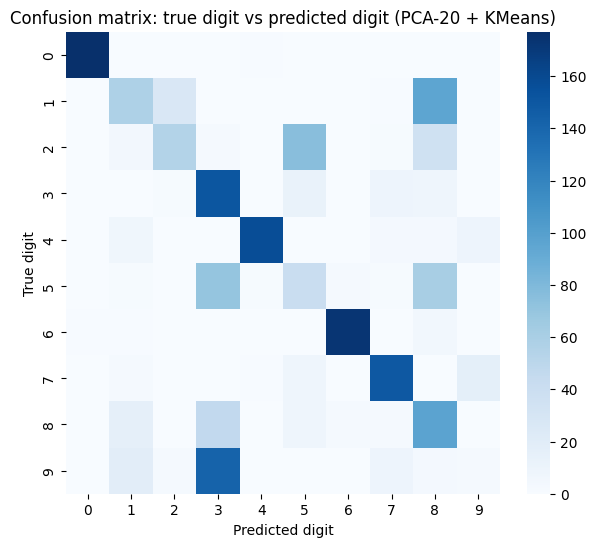

In [3]:
from scipy.optimize import linear_sum_assignment

pca_k = PCA(n_components=20, random_state=42)
X_k = pca_k.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=10, n_init=50, random_state=42)
clusters = kmeans.fit_predict(X_k)

cm_tc = confusion_matrix(y, clusters)
row_ind, col_ind = linear_sum_assignment(-cm_tc)
cluster_to_digit = {cluster: digit for digit, cluster in zip(row_ind, col_ind)}

y_pred = np.array([cluster_to_digit[c] for c in clusters])

precision_per_digit = {d: np.mean(y_pred[y == d] == d) for d in range(10)}

recall_per_cluster = {}
for c in range(10):
    mask = (clusters == c)
    recall_per_cluster[c] = 0.0 if mask.sum() == 0 else np.mean(y[mask] == cluster_to_digit[c])

gini_index = np.mean(y_pred == y)

print("Optimal cluster -> digit mapping:", cluster_to_digit)

print("\nPrecision per digit (fraction correctly clustered):")
for d in range(10):
    print(f"Digit {d}: {precision_per_digit[d]:.3f}")

print("\nRecall/purity per cluster:")
for c in range(10):
    print(f"Cluster {c}: {recall_per_cluster[c]:.3f} (mapped digit = {cluster_to_digit[c]})")

print("\nGini-index (overall correct fraction):", gini_index)

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion matrix: true digit vs predicted digit (PCA-20 + KMeans)")
plt.xlabel("Predicted digit")
plt.ylabel("True digit")
plt.show()

### Part 3: 3D PCA Projection

Extend your analysis from 2D to 3D. With an extra dimension, you should capture more variance and see better separation of digit classes.

1. Create a 3D PCA model with 3 principal components

2. Transform the data to 3D space

3. Create a 3D scatter plot where:
    - Each digit class has a different color

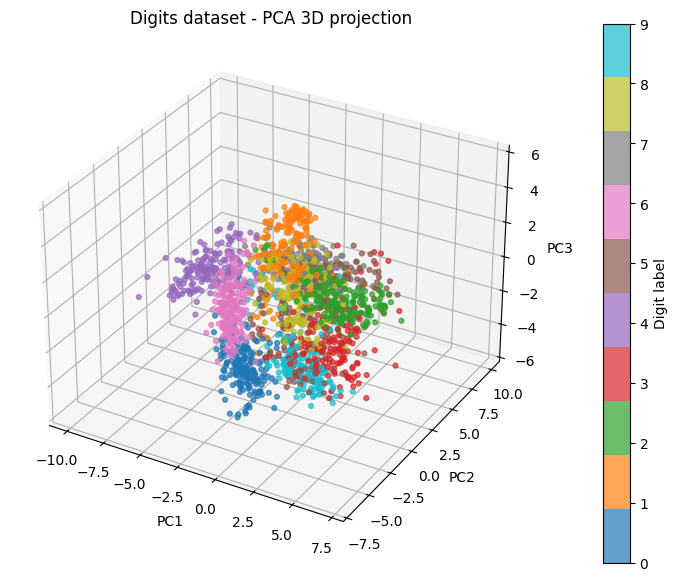

Explained variance ratio (3D): [0.12033916 0.09561054 0.08444415]
Total explained variance (3D): 0.3003938539345734


In [4]:
pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap="tab10", s=12, alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Digits dataset - PCA 3D projection")

cbar = fig.colorbar(p, ax=ax, pad=0.1)
cbar.set_label("Digit label")

plt.show()

print("Explained variance ratio (3D):", pca_3d.explained_variance_ratio_)
print("Total explained variance (3D):", pca_3d.explained_variance_ratio_.sum())


### Part 4: Optimal Dimensionality Selection

**How many dimensions do we actually need?**

Too few and we lose important information, too many and we might overfit or negate the benefits of dimensionality reduction. We need to find the sweet spot.

1. Run PCA with increasing numbers of components:
    - For each k from 1 to 63:
        - Fit a PCA model with k components
        - Calculate the explained variance ratio

2. Create a plot showing:
    - X-axis: component number (k = 1 to 63)
    - Y-axis: explained variance ratio

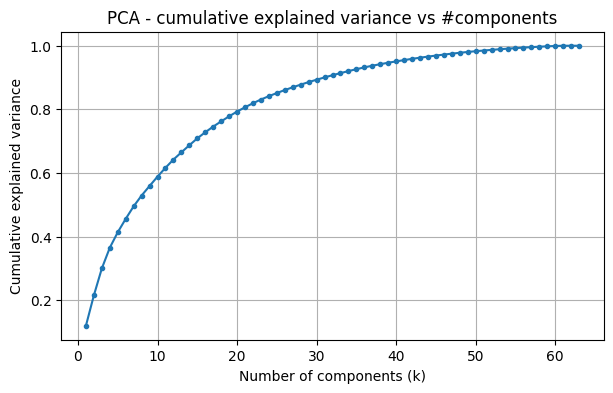

In [5]:
explained = []
cumulative = []

for k in range(1, 64):
    p = PCA(n_components=k, random_state=42)
    p.fit(X_scaled)
    total = np.sum(p.explained_variance_ratio_)
    explained.append(total)
    cumulative.append(total)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 64), cumulative, marker='o', markersize=3)
plt.xlabel("Number of components (k)")
plt.ylabel("Cumulative explained variance")
plt.title("PCA - cumulative explained variance vs #components")
plt.grid(True)
plt.show()


## 📝 Exercise 2: Anomaly Detection in Facebook Spatial Likes

In this exercise, you will apply the low-dimensional phenomenon to detect anomalous users in a real Facebook dataset. The dataset contains information about users' likes across different content categories.

- Dataset Description:
    - 9,000 users
    - 210 content categories (different categories of pages on Facebook)
    - 6 months of data

- Each entry represents the number of likes a user gave to pages in that category

- Data Format:
    - Rows = users
    - Columns = content categories
    - Matrix shape: 9000 × 210

### Part 0: Data Loading and Exploration

- Load the data `spatial_data.txt` and extract the content categories (exclude the first column which is user IDs).

In [6]:
# Load data
data = np.loadtxt('spatial_data.txt')
FBSpatial = data[:,1:]  # Remove user ID column
print(f"Data shape: {FBSpatial.shape}")
print(f"Number of users: {FBSpatial.shape[0]}")
print(f"Number of categories: {FBSpatial.shape[1]}")

Data shape: (8982, 210)
Number of users: 8982
Number of categories: 210


- Check the total number of likes for each user (the row sums).

Text(0.5, 0, 'Users')

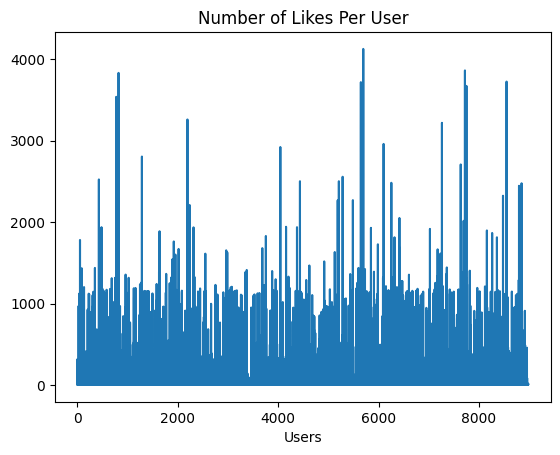

In [7]:
FBSnorm = np.linalg.norm(FBSpatial,axis=1,ord=1)
plt.plot(FBSnorm)
plt.title('Number of Likes Per User')
plt.xlabel('Users')

In many real-world datasets, most "normal" observations lie approximately in a low-dimensional subspace. This is called the low-dimensional phenomenon. What does this mean?

- Normal users might have similar like patterns across 210 categories
- These patterns can be summarized by just 20-25 principal components
- Anomalous users break this pattern - they have unusual preference profiles 

Let's check whether the low dimensional phenomenon holds.

Text(0.5, 1.0, 'Singular Values of Spatial Like Matrix')

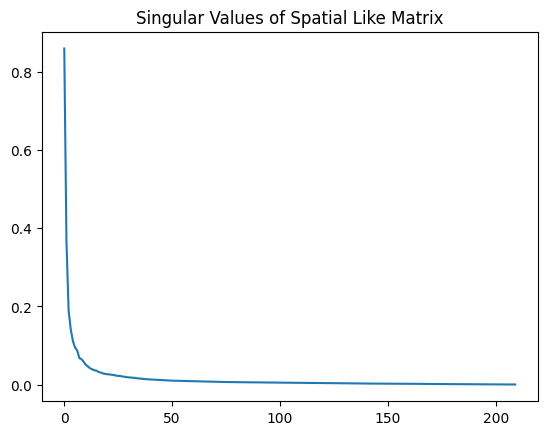

In [8]:
u,s,vt = np.linalg.svd(FBSpatial,full_matrices=False)
plt.plot(s/np.linalg.norm(FBSpatial))
plt.title('Singular Values of Spatial Like Matrix')

### Part 1: Build the Normal Model and Extract Anomalies

Separate the portion of the data lying in the normal space from the amonalous space.

1. Compute SVD of FBSpatial

2. Use first 25 columns (which captures ~80-85% of the variance) to project data onto normal subspace

3. Calculate residuals as anomalous component

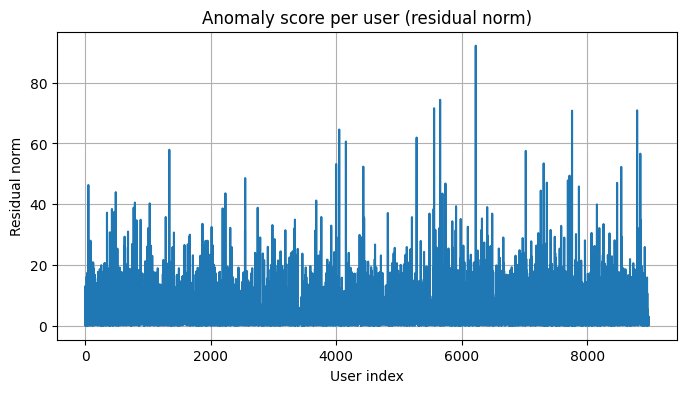

Anomaly scores computed. Shape: (8982,)


In [12]:
U, s, Vt = np.linalg.svd(FBSpatial, full_matrices=False)

k = 25
Uk = U[:, :k]
Sk = s[:k]
Vtk = Vt[:k, :]
A_k = (Uk * Sk) @ Vtk
R = FBSpatial - A_k
anomaly_scores = np.linalg.norm(R, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(anomaly_scores)
plt.title("Anomaly score per user (residual norm)")
plt.xlabel("User index")
plt.ylabel("Residual norm")
plt.grid(True)
plt.show()

print("Anomaly scores computed. Shape:", anomaly_scores.shape)


### Part 2: Identify Top 30 Anomalous Users

Find the 30 users with largest anomaly scores and visualize their position relative to overall user activity.

Top 30 anomalous users (user_index, anomaly_score):
01. user_index=6225  score=92.1256
02. user_index=5657  score=74.3315
03. user_index=5561  score=71.5683
04. user_index=8796  score=70.8756
05. user_index=7759  score=70.7598
06. user_index=4049  score=64.5577
07. user_index=5283  score=61.9178
08. user_index=4156  score=60.6101
09. user_index=1342  score=57.8929
10. user_index=7022  score=57.5379
11. user_index=8847  score=56.6210
12. user_index=7307  score=53.4202
13. user_index=4000  score=53.2057
14. user_index=4433  score=52.3507
15. user_index=8543  score=52.2668
16. user_index=7719  score=49.4013
17. user_index=2551  score=48.5913
18. user_index=7693  score=47.8356
19. user_index=7358  score=47.0989
20. user_index=8477  score=47.0185
21. user_index=5742  score=46.8098
22. user_index=52  score=46.3190
23. user_index=7869  score=45.8319
24. user_index=7261  score=44.4577
25. user_index=489  score=43.9584
26. user_index=2236  score=43.5839
27. user_index=5694  score=43.5106
28. us

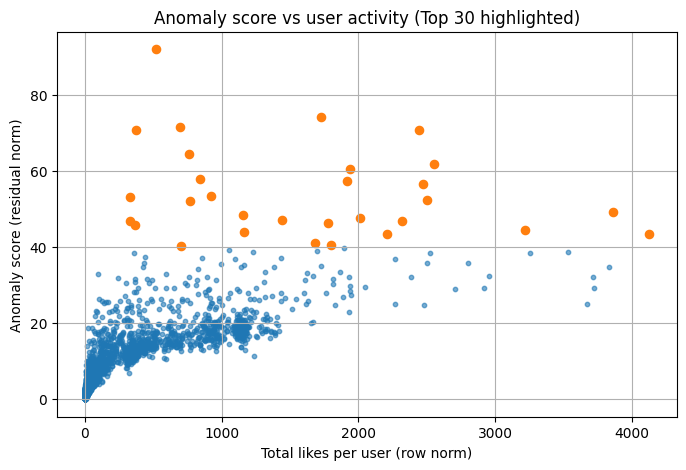

In [10]:
top30_idx = np.argsort(anomaly_scores)[-30:][::-1]

first_col = data[:, 0]
unique_first = np.unique(first_col)

if len(unique_first) > 100:   # looks like real IDs
    ids = first_col.astype(int)
    id_label = "user_id"
else:
    ids = np.arange(len(anomaly_scores))
    id_label = "user_index"

print(f"Top 30 anomalous users ({id_label}, anomaly_score):")
for i, idx in enumerate(top30_idx, 1):
    print(f"{i:02d}. {id_label}={int(ids[idx])}  score={anomaly_scores[idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(FBSnorm, anomaly_scores, s=10, alpha=0.6)
plt.scatter(FBSnorm[top30_idx], anomaly_scores[top30_idx], s=35)
plt.xlabel("Total likes per user (row norm)")
plt.ylabel("Anomaly score (residual norm)")
plt.title("Anomaly score vs user activity (Top 30 highlighted)")
plt.grid(True)
plt.show()

### Part 3: Visualize Patterns of Anomalous Users

Plot the like patterns (across the 210 categories) for 9 of the top anomalous users.

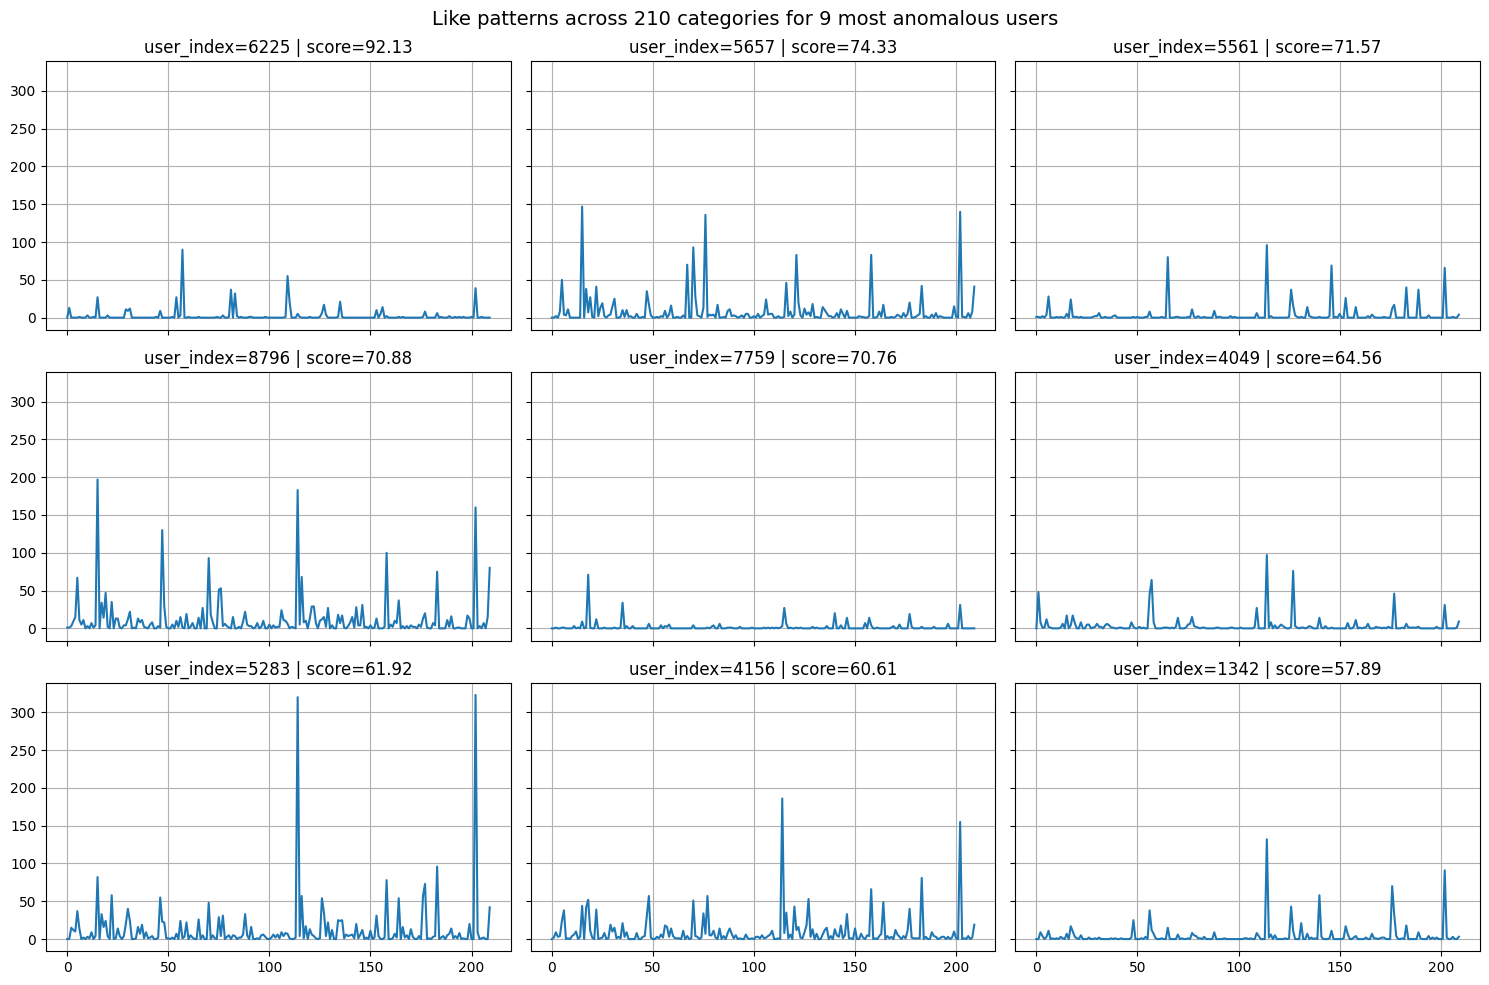

In [11]:
top9_idx = top30_idx[:9]

first_col = data[:, 0]
unique_first = np.unique(first_col)
if len(unique_first) > 100:
    ids = first_col.astype(int)
    id_label = "user_id"
else:
    ids = np.arange(len(anomaly_scores))
    id_label = "user_index"

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

for ax, idx in zip(axes.ravel(), top9_idx):
    ax.plot(FBSpatial[idx, :])
    ax.set_title(f"{id_label}={int(ids[idx])} | score={anomaly_scores[idx]:.2f}")
    ax.grid(True)

fig.suptitle("Like patterns across 210 categories for 9 most anomalous users", fontsize=14)
plt.tight_layout()
plt.show()